# 03 Baseline Modeling

## 목표
- 비교 가능한 기준으로 pseudo anomaly label을 정의한다.
- `rolling z-score`, `EWMA`, `Isolation Forest`를 같은 test 구간에서 비교한다.
- 단순 모델이 어떤 trade-off를 보이는지 정량적으로 정리한다.


In [1]:
import os
from pathlib import Path
import warnings

# 프로젝트/데이터/출력 경로를 먼저 고정해두면 이후 셀을 다시 실행해도 재현성이 유지된다.
PROJECT_DIR = Path("/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects")
DATA_DIR = Path("/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Data")
OUTPUT_DIR = PROJECT_DIR / "outputs" / "03_baseline_modeling"
MPLCONFIG_DIR = PROJECT_DIR / ".mplconfig"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid", context="notebook")

RAW_PATH = DATA_DIR / "sub_upbit_eth_min_tick.csv"
FEAT_PATH = DATA_DIR / "sub_upbit_eth_min_feature_labels.pkl"

print(f"RAW_PATH exists: {RAW_PATH.exists()}")
print(f"FEAT_PATH exists: {FEAT_PATH.exists()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


RAW_PATH exists: True
FEAT_PATH exists: True
OUTPUT_DIR: /Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Projects/FTS_Projects/outputs/03_baseline_modeling


### 결과 해석
- 모델링 노트북도 앞선 노트북과 같은 경로 체계를 쓰도록 고정해두면, 결과 파일이 섞이지 않고 재현성이 좋아집니다. `Isolation Forest`까지 한 번에 불러와 이후 셀에서 바로 비교할 수 있게 준비했습니다.
- 문제는 시각화 캐시/라이브러리 경로가 세션마다 흔들릴 수 있다는 점인데, 원인은 노트북 환경의 기본 캐시 경로가 쓰기 제한을 받기 때문입니다. 프로젝트 내부에 설정 폴더를 두어 실행 안정성을 확보했습니다.


## 1. 모델링용 데이터셋과 Pseudo Label 정의

이 단계에서는 raw 시계열과 기존 feature 파일을 합쳐 모델링용 master table을 만들고, 비교 평가용 pseudo anomaly label을 정의합니다.


In [2]:
# raw 데이터에서 anomaly 판단에 직접 쓸 파생변수를 다시 계산한다.
raw = pd.read_csv(RAW_PATH, parse_dates=["time"]).sort_values("time").reset_index(drop=True)
raw["ret_1"] = raw["close"].pct_change()

# 로그수익률은 변동성 계산에 자주 쓰이는 표현이라 따로 만든다.
raw["log_ret_1"] = np.log(raw["close"]).diff()

# rv_30: 최근 30분 실현 변동성, vol_z_60: 최근 60분 기준 거래량 burst 정도
raw["rv_30"] = raw["log_ret_1"].rolling(30).std() * np.sqrt(30)
raw["vol_z_60"] = (
    (raw["volume"] - raw["volume"].rolling(60).mean())
    / raw["volume"].rolling(60).std()
)

# 연속 1분 구간만 쓰기 위해 gap 정보를 만든다.
raw["gap_min"] = raw["time"].diff().dt.total_seconds().div(60)
raw["is_continuous"] = raw["gap_min"].fillna(1).eq(1)

# feature pickle과 merge할 때 컬럼명이 겹치지 않도록 raw 쪽 이름을 일부 바꾼다.
raw_model = raw[
    ["time", "volume", "close", "ret_1", "log_ret_1", "rv_30", "vol_z_60", "gap_min", "is_continuous"]
].copy().rename(columns={"volume": "raw_volume", "close": "raw_close"})

feat = pd.read_pickle(FEAT_PATH).sort_index().copy()
feat.index = pd.to_datetime(feat.index)

# raw 파생변수와 기존 feature set을 시간 기준으로 합친다.
master = raw_model.merge(feat, left_on="time", right_index=True, how="inner")

# 지나치게 작은 거래량 구간은 데이터 왜곡이 심할 수 있어 하위 5%는 제외한다.
volume_floor = master.loc[master["raw_volume"] > 0, "raw_volume"].quantile(0.05)
master = master[(master["is_continuous"]) & (master["raw_volume"] >= volume_floor)].copy().reset_index(drop=True)

# baseline feature는 앞선 EDA에서 separation이 좋았고, 중복이 너무 심하지 않은 변수 위주로 고른다.
feature_cols = [
    "ret_5",
    "ret_10",
    "ret_20",
    "momentum_rsi",
    "trend_macd_diff",
    "trend_aroon_ind",
    "volume_mfi",
    "std_30",
    "vol_std_30",
    "volatility_atr",
]

# 모델에 필요한 핵심 컬럼에 결측이 없는 행만 남긴다.
master = master.dropna(subset=["ret_1", "rv_30", "vol_z_60"] + feature_cols).reset_index(drop=True)

# 시계열 데이터는 랜덤 분할보다 시간 순서 분할이 중요하다.
split_idx = int(len(master) * 0.7)
train = master.iloc[:split_idx].copy()
test = master.iloc[split_idx:].copy()

# pseudo_event는 train 구간에서 extreme threshold를 정하고, 같은 기준을 test에 적용한다.
# 여기서 99.5% 분위수는 '정말 드문 극단 구간'만 anomaly 후보로 보기 위한 절충안이다.
q = 0.995
thr_abs_ret = train["ret_1"].abs().quantile(q)
thr_rv = train["rv_30"].quantile(q)
thr_vol = train["vol_z_60"].quantile(q)

for part in [train, test]:
    part["pseudo_event"] = (
        part["ret_1"].abs().ge(thr_abs_ret)
        | part["rv_30"].ge(thr_rv)
        | part["vol_z_60"].ge(thr_vol)
    ).astype(int)

master.loc[train.index, "pseudo_event"] = train["pseudo_event"]
master.loc[test.index, "pseudo_event"] = test["pseudo_event"]

feature_selection = pd.DataFrame({"feature": feature_cols})
pseudo_event_thresholds = pd.DataFrame(
    {
        "metric": ["volume_floor", "abs_ret_1_q995", "rv_30_q995", "vol_z_60_q995"],
        "value": [volume_floor, thr_abs_ret, thr_rv, thr_vol],
    }
)
train_test_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "row_count": [len(train), len(test)],
        "start_time": [train["time"].min(), test["time"].min()],
        "end_time": [train["time"].max(), test["time"].max()],
        "event_rate": [train["pseudo_event"].mean(), test["pseudo_event"].mean()],
    }
)

feature_selection.to_csv(OUTPUT_DIR / "baseline_feature_list.csv", index=False)
pseudo_event_thresholds.to_csv(OUTPUT_DIR / "pseudo_event_thresholds.csv", index=False)
train_test_summary.to_csv(OUTPUT_DIR / "train_test_summary.csv", index=False)

display(pseudo_event_thresholds)
display(train_test_summary)
display(feature_selection)


,metric,value
0,volume_floor,0.605510
1,abs_ret_1_q995,0.009406
2,rv_30_q995,0.043980
3,vol_z_60_q995,5.248857


,split,row_count,start_time,end_time,event_rate
0,train,582559,2018-01-01 00:43:00,2019-04-14 11:30:00,0.013123
1,test,249669,2019-04-14 11:31:00,2019-11-03 10:03:00,0.007178


,feature
0,ret_5
1,ret_10
2,ret_20
3,momentum_rsi
4,trend_macd_diff
5,trend_aroon_ind
6,volume_mfi
7,std_30
8,vol_std_30
9,volatility_atr


### 결과 해석
- 모델링용 최종 데이터는 **832,228행**이고, 시간 분할은 **train 582,559행 / test 249,669행**입니다. 저유동성 필터 기준 거래량 하한은 약 **0.6055**, pseudo event 임계값은 `|ret_1| >= 0.00941`, `rv_30 >= 0.04398`, `vol_z_60 >= 5.24886`로 잡혔습니다.
- train 이벤트 비율은 약 **1.31%**, test는 **0.72%**로 test가 더 조용한 장세입니다. 문제는 시기별 이벤트 밀도가 다르다는 점이고, 원인은 레짐 변화이며, 해결방안은 `time-based split 유지`, `train 기준 threshold 사용`, `test 성능을 별도로 해석`하는 것입니다.


## 2. Baseline Score 계산과 예측 생성

세 모델을 같은 alert budget에서 비교하기 위해, score threshold는 train 이벤트 비율에 맞춰 보정합니다.


In [3]:
# rolling z-score는 현재 값이 직전 60분 평균/표준편차 대비 얼마나 이례적인지를 본다.
# shift(1)을 주는 이유는 현재 시점 정보를 자기 자신의 기준값 계산에 넣지 않기 위해서다.
master["zscore_ret_1"] = (
    (master["ret_1"] - master["ret_1"].rolling(60).mean().shift(1))
    / master["ret_1"].rolling(60).std().shift(1)
).abs()

# EWMA(Exponentially Weighted Moving Average)는 최근 데이터에 더 큰 가중치를 주는 평균/표준편차 방식이다.
# 급격한 상태 변화에 rolling 평균보다 더 빠르게 반응할 수 있다.
master["ewm_mean_ret_1"] = master["ret_1"].ewm(span=60, adjust=False).mean().shift(1)
master["ewm_std_ret_1"] = master["ret_1"].ewm(span=60, adjust=False).std(bias=False).shift(1)
master["ewma_score"] = (
    (master["ret_1"] - master["ewm_mean_ret_1"]).abs() / master["ewm_std_ret_1"]
)

# train 이벤트 비율을 alert budget으로 사용하면, z-score와 EWMA를 공정하게 비교할 수 있다.
train_event_rate = train["pseudo_event"].mean()
zscore_threshold = master.loc[: split_idx - 1, "zscore_ret_1"].dropna().quantile(1 - train_event_rate)
ewma_threshold = master.loc[: split_idx - 1, "ewma_score"].dropna().quantile(1 - train_event_rate)

master["pred_zscore"] = master["zscore_ret_1"].ge(zscore_threshold).astype(int)
master["pred_ewma"] = master["ewma_score"].ge(ewma_threshold).astype(int)

# Isolation Forest는 '드문 점일수록 트리에서 빨리 고립된다'는 아이디어를 쓰는 비지도 이상탐지 모델이다.
# 다변량 정보를 쓰므로 단일 수익률 기반 baseline과 다르게 동작할 수 있다.
scaler = StandardScaler()
X_train = scaler.fit_transform(train[feature_cols])
X_test = scaler.transform(test[feature_cols])

iforest = IsolationForest(
    n_estimators=200,
    contamination=train_event_rate,
    random_state=42,
    n_jobs=-1,
)
iforest.fit(X_train)

test["pred_iforest"] = (iforest.predict(X_test) == -1).astype(int)
master.loc[test.index, "pred_iforest"] = test["pred_iforest"]

threshold_summary = pd.DataFrame(
    {
        "metric": ["train_event_rate", "zscore_threshold", "ewma_threshold"],
        "value": [train_event_rate, zscore_threshold, ewma_threshold],
    }
)

baseline_test_predictions = master.loc[test.index, [
    "time",
    "raw_close",
    "raw_volume",
    "ret_1",
    "rv_30",
    "vol_z_60",
    "pseudo_event",
    "zscore_ret_1",
    "ewma_score",
    "pred_zscore",
    "pred_ewma",
    "pred_iforest",
]].copy()

baseline_test_predictions.to_csv(OUTPUT_DIR / "baseline_test_predictions.csv", index=False)

display(threshold_summary)
display(baseline_test_predictions.head())


,metric,value
0,train_event_rate,0.013123
1,zscore_threshold,3.428654
2,ewma_threshold,3.247386


,time,raw_close,raw_volume,ret_1,rv_30,vol_z_60,pseudo_event,zscore_ret_1,ewma_score,pred_zscore,pred_ewma,pred_iforest
582559,2019-04-14 11:31:00,189250,33.881855,0.000000,0.002249,0.363340,0.000000,0.098482,0.001030,0,0,0.000000
582560,2019-04-14 11:32:00,189200,45.375591,-0.000264,0.002249,0.755810,0.000000,0.404844,0.535424,0,0,0.000000
582561,2019-04-14 11:33:00,189200,9.190000,0.000000,0.002232,-0.566338,0.000000,0.060412,0.016740,0,0,0.000000
582562,2019-04-14 11:34:00,189350,3.213239,0.000793,0.002366,-0.786635,0.000000,1.621812,1.666607,0,0,0.000000
582563,2019-04-14 11:35:00,189400,24.810369,0.000264,0.002376,-0.011841,0.000000,0.580359,0.497501,0,0,0.000000


### 결과 해석
- train 이벤트 비율에 맞춰 보정한 threshold는 `z-score ≈ 3.429`, `EWMA ≈ 3.247`로 잡혔습니다. 이 방식 덕분에 z-score와 EWMA는 비슷한 alert budget에서 비교되고, Isolation Forest는 같은 contamination을 쓰되 다변량 구조를 활용합니다.
- 문제는 test 구간 이벤트 비율이 train보다 낮아 동일 budget이라도 test에서는 alert 비중이 달라질 수 있다는 점입니다. 원인은 레짐 drift이며, 해결방안은 `time-based calibration 유지`, `test alert_rate와 precision/recall을 함께 해석`하는 것입니다.


## 3. 정량 평가

precision, recall, F1, FPR(false positive rate)을 기준으로 세 baseline을 비교합니다.


,model,n_test,event_rate,alert_rate,precision,recall,f1,false_positive_rate
0,rolling_zscore,249669,0.007178,0.011752,0.190184,0.311384,0.236140,0.009585
1,ewma,249669,0.007178,0.011976,0.186622,0.311384,0.233375,0.009811
2,iforest,249669,0.007178,0.001770,0.262443,0.064732,0.103850,0.001315


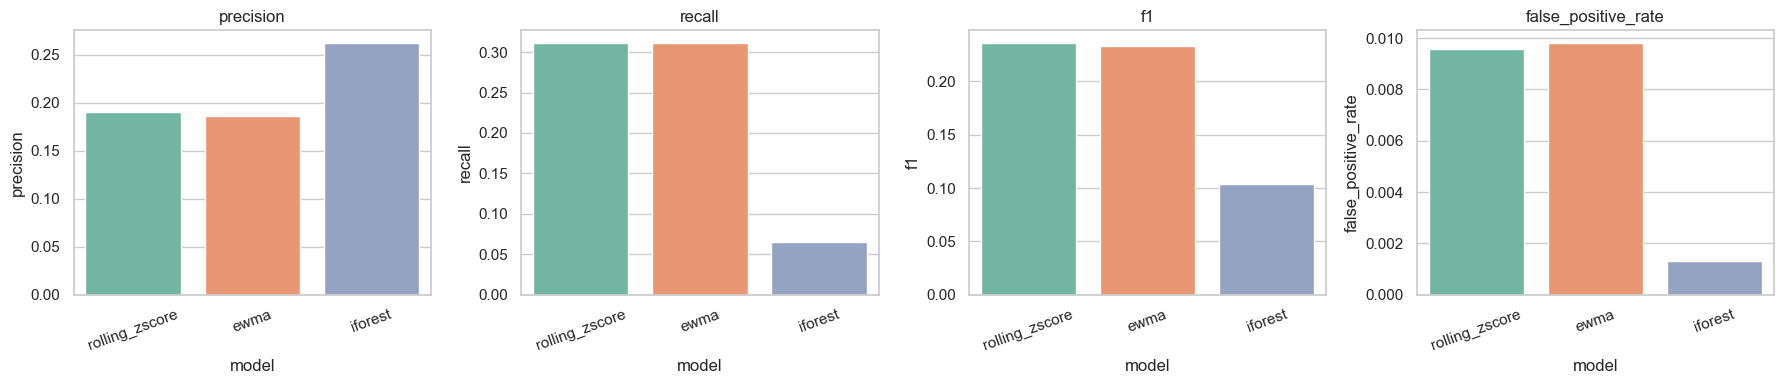

In [4]:
# FPR(false positive rate)은 '정상 구간 중 잘못 울린 비율'을 뜻한다.
# anomaly detection에서는 precision/recall만큼이나 false alarm을 얼마나 줄였는지가 중요하다.
def evaluate_predictions(eval_df, pred_col, model_name):
    y_true = eval_df["pseudo_event"].astype(int)
    y_pred = eval_df[pred_col].fillna(0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "model": model_name,
        "n_test": len(eval_df),
        "event_rate": y_true.mean(),
        "alert_rate": y_pred.mean(),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "false_positive_rate": fp / (fp + tn),
    }

metrics_rows = []
test_eval = master.loc[test.index].copy()
metrics_rows.append(evaluate_predictions(test_eval, "pred_zscore", "rolling_zscore"))
metrics_rows.append(evaluate_predictions(test_eval, "pred_ewma", "ewma"))
metrics_rows.append(evaluate_predictions(test, "pred_iforest", "iforest"))

baseline_metrics = pd.DataFrame(metrics_rows).sort_values("f1", ascending=False).reset_index(drop=True)
baseline_metrics.to_csv(OUTPUT_DIR / "baseline_metrics.csv", index=False)

display(baseline_metrics)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metric_cols = ["precision", "recall", "f1", "false_positive_rate"]

for ax, metric_name in zip(axes, metric_cols):
    sns.barplot(data=baseline_metrics, x="model", y=metric_name, ax=ax, palette="Set2")
    ax.set_title(metric_name)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### 결과 해석
- 현재 실행 기준 test 성능은 `rolling_zscore`가 **F1 ≈ 0.236**, `EWMA`가 **F1 ≈ 0.233**, `Isolation Forest`가 **F1 ≈ 0.104**입니다. 다만 precision은 `Isolation Forest ≈ 0.262`로 가장 높고, recall은 `z-score/EWMA ≈ 0.311`로 더 높아 `보수형 vs 탐지형` trade-off가 분명합니다.
- FPR은 `z-score ≈ 0.0096`, `EWMA ≈ 0.0098`, `Isolation Forest ≈ 0.0013`으로 Isolation Forest가 가장 낮습니다. 문제는 multivariate 모델이 정확히는 더 보수적으로만 동작한다는 점이고, 원인은 현재 pseudo label이 방향성/극단값 중심이라 다변량 anomaly와 완전히 일치하지 않기 때문입니다. 해결방안은 `pseudo label 개선`, `IF contamination/feature set 튜닝`, `평가 지표 다변화`입니다.


## 4. 이벤트 창에서 모델 반응 보기

정량 지표만으로는 감이 잘 오지 않으므로, test 구간의 첫 이벤트 주변에서 각 모델이 어떻게 반응하는지 시각적으로 확인합니다.


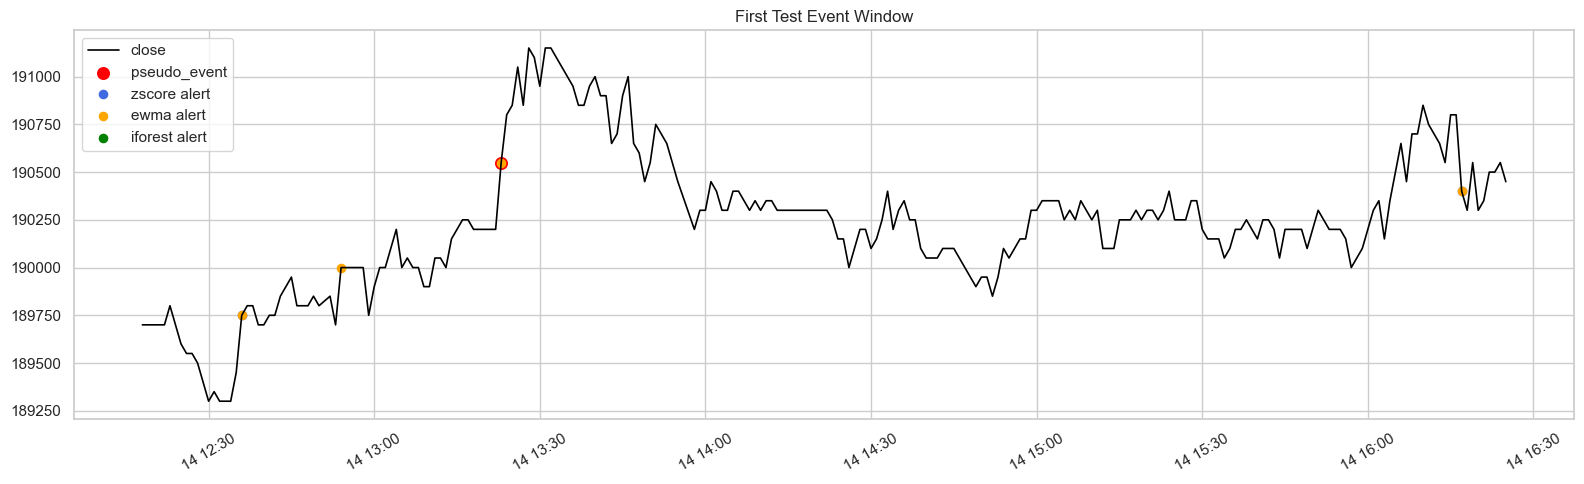

,time,raw_close,pseudo_event,pred_zscore,pred_ewma,pred_iforest
582602,2019-04-14 12:18:00,189700,0.000000,0,0,0.000000
582603,2019-04-14 12:19:00,189700,0.000000,0,0,0.000000
582604,2019-04-14 12:20:00,189700,0.000000,0,0,0.000000
582605,2019-04-14 12:21:00,189700,0.000000,0,0,0.000000
582606,2019-04-14 12:22:00,189700,0.000000,0,0,0.000000
582607,2019-04-14 12:23:00,189800,0.000000,0,0,0.000000
582608,2019-04-14 12:24:00,189700,0.000000,0,0,0.000000
582609,2019-04-14 12:25:00,189600,0.000000,0,0,0.000000
582610,2019-04-14 12:26:00,189550,0.000000,0,0,0.000000
582611,2019-04-14 12:27:00,189550,0.000000,0,0,0.000000


first_event_time: 2019-04-14 13:23:00
window alert counts: {'pseudo_event': 1.0, 'pred_zscore': 2.0, 'pred_ewma': 4.0, 'pred_iforest': 0.0}


In [5]:
# test 구간에서 첫 pseudo event를 기준으로 앞 60분, 뒤 180분 구간을 잘라본다.
first_event_idx = test.index[test["pseudo_event"] == 1][0]
window_start = max(0, first_event_idx - 60)
window_end = min(len(master) - 1, first_event_idx + 180)

baseline_window_sample = master.loc[
    window_start:window_end,
    ["time", "raw_close", "pseudo_event", "pred_zscore", "pred_ewma", "pred_iforest"],
].copy()

# train 구간에는 pred_iforest가 없을 수 있으므로 시각화용으로만 0으로 채운다.
window_plot = baseline_window_sample.fillna({"pred_iforest": 0})
baseline_window_sample.to_csv(OUTPUT_DIR / "baseline_window_sample.csv", index=False)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(window_plot["time"], window_plot["raw_close"], color="black", linewidth=1.2, label="close")

# 이벤트/경보 시점은 점으로 표시해 어느 모델이 먼저 혹은 많이 반응했는지 본다.
event_points = window_plot[window_plot["pseudo_event"] == 1]
zscore_points = window_plot[window_plot["pred_zscore"] == 1]
ewma_points = window_plot[window_plot["pred_ewma"] == 1]
iforest_points = window_plot[window_plot["pred_iforest"] == 1]

ax.scatter(event_points["time"], event_points["raw_close"], color="red", s=70, label="pseudo_event")
ax.scatter(zscore_points["time"], zscore_points["raw_close"], color="royalblue", s=35, label="zscore alert")
ax.scatter(ewma_points["time"], ewma_points["raw_close"], color="orange", s=35, label="ewma alert")
ax.scatter(iforest_points["time"], iforest_points["raw_close"], color="green", s=35, label="iforest alert")

ax.set_title("First Test Event Window")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

display(baseline_window_sample.head(15))
print("first_event_time:", master.loc[first_event_idx, "time"])
print(
    "window alert counts:",
    window_plot[["pseudo_event", "pred_zscore", "pred_ewma", "pred_iforest"]].sum().to_dict(),
)


### 결과 해석
- 첫 test 이벤트는 **2019-04-14 13:23:00** 근처에서 발생했고, 이 창에서 `pseudo_event = 1개`에 대해 `z-score = 2개`, `EWMA = 4개`, `Isolation Forest = 0개`의 경보가 나왔습니다. 즉 z-score/EWMA는 주변 변화를 넓게 잡고, Isolation Forest는 같은 구간에서 반응하지 않을 정도로 보수적입니다.
- 문제는 이벤트 창 단위로 보면 EWMA가 조금 더 민감하게 주변 구간까지 울릴 수 있다는 점입니다. 원인은 EWMA가 최근 변화에 빠르게 반응하는 구조이기 때문이며, 해결방안은 `cooldown rule`, `연속 경보 병합`, `window 기반 이벤트 평가`를 추가하는 것입니다.


## 5. Next Step

1. `baseline_metrics.csv`를 기준으로 주 모델을 하나 고르기보다, `탐지형(z-score/EWMA)`과 `보수형(Isolation Forest)` 역할을 분리해 해석합니다.
2. 다음 단계에서는 `04_threshold_tuning_and_rules.ipynb`에서 threshold, cooldown, event merging 규칙을 조정해 false alarm을 줄입니다.
3. 이후 `05_anomaly_dashboard_story.ipynb` 또는 발표 자료에서 `왜 이 모델 조합을 선택했는지`를 반도체 공정 모니터링 언어로 설명하면 포트폴리오 완성도가 올라갑니다.
